In [1]:
import numpy as np
import pandas as pd
from anndata import AnnData
import scanpy as sc
import multiprocessing as mp
from tqdm import tqdm

# load package

In [2]:
import os
import sys
sys.path.insert(1, '/home/nas3/biod/yangchenghui/proj2/UniG_master/src')
import unig as ug
ug.__version__

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'1.1'

In [3]:
workdir = '/home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/'
ug.settings.set_workdir(workdir)

Saving results in: /home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/


# Data preprocessing

In [4]:
data_path = "/home/nas3/biod/yangchenghui/proj2/P22 mouse brain data/"
P22_RNA_adata = sc.read_h5ad(data_path + 'P22_RNA_adata.h5ad')
P22_ATAC_adata = sc.read_h5ad(data_path + 'P22_ATAC_adata.h5ad')
P22_RNA_adata, P22_ATAC_adata

(AnnData object with n_obs × n_vars = 9215 × 18005
     obs: 'batch', 'label'
     uns: 'label_colors'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 9215 × 121068
     obs: 'batch', 'label'
     obsm: 'spatial')

RNA processing

In [5]:
P22_RNA_adata = ug.pp.preprocess_rna(P22_RNA_adata)
P22_RNA_adata

AnnData object with n_obs × n_vars = 9215 × 18005
    obs: 'batch', 'label'
    var: 'n_cells', 'moran_I', 'spatial_qval', 'spatially_variable', 'spatially_variable_rank', 'variable'
    uns: 'label_colors', 'log1p', 'spatial_neighbors', 'moranI', 'svg_top_genes'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

ATAC processing

In [6]:
P22_ATAC_adata = ug.pp.preprocess_atac(P22_ATAC_adata)
peaks_all = list(P22_ATAC_adata.var_names)
P22_ATAC_adata

AnnData object with n_obs × n_vars = 9215 × 121027
    obs: 'batch', 'label'
    var: 'n_cells', 'chr', 'start', 'end'
    obsm: 'spatial'

For each variable gene, select ATAC peaks that fall within the gene body or in its upstream/downstream regions 

In [9]:
gene_info = pd.read_csv('/home/nas3/biod/yangchenghui/nas2_ych/FGOT-master/data/P22mousebrain_data/mm10_TSS.txt', sep = '\t')
gene_info = gene_info.rename(columns={'start': 'starts','end': 'ends','Gene': 'genes'})
gene_info.head()

,chr,starts,ends,genes
1,chr1,3466587,3513553,Gm1992
2,chr1,3205901,3671498,Xkr4
3,chr1,3905739,3986215,Gm37381
4,chr1,4292981,4409187,Rp1_2
5,chr1,3999557,4409241,Rp1


In [10]:
genes_selected = P22_RNA_adata.var_names[P22_RNA_adata.var['spatially_variable']].tolist()
filtered_genes, filtered_peaks, gene_peaks = ug.pp.select_gene_peaks_by_genes_location(gene_info, genes_selected, peaks_all)

Preprocessing gene_info:


27916it [00:00, 47309.77it/s]


Search the genes-peaks correspondence based on gene_info and scope:


27916it [00:57, 488.92it/s]


Search the filtered peaks:


100%|██████████| 1797/1797 [00:00<00:00, 194056.75it/s]

There are 1797 genes that can be identified from the TSS information.
There are 50092 peaks near the upstream and downstream of the above genes.


In [11]:
P22_RNA_adata_fltr = P22_RNA_adata[:,filtered_genes]
P22_ATAC_adata_fltr = P22_ATAC_adata[:,filtered_peaks]
P22_RNA_adata_fltr,P22_ATAC_adata_fltr

P22_RNA_adata_fltr.write(workdir + "/P22_RNA_adata_fltr.h5ad")
P22_ATAC_adata_fltr.write(workdir + "/P22_ATAC_adata_fltr.h5ad")

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


gene-peak relation

In [12]:
from scipy import sparse
gene_to_idx = {gene: i for i, gene in enumerate(filtered_genes)}
peak_to_idx = {peak: i for i, peak in enumerate(filtered_peaks)}
rows = []
cols = []

filtered_peaks_set = set(filtered_peaks)
for gene in tqdm(filtered_genes):
    if gene in gene_peaks:
        current_peaks = gene_peaks[gene]
        valid_peaks = [p for p in current_peaks if p in peak_to_idx]
        if valid_peaks:
            g_idx = gene_to_idx[gene]
            p_idxs = [peak_to_idx[p] for p in valid_peaks]
            rows.extend([g_idx] * len(p_idxs))
            cols.extend(p_idxs)
data = np.ones(len(rows), dtype=int)
sparse_mat = sparse.coo_matrix((data, (rows, cols)), 
                               shape=(len(filtered_genes), len(filtered_peaks))).tocsr()
adata_GP = sc.AnnData(X=sparse_mat)
adata_GP.obs_names = filtered_genes
adata_GP.var_names = filtered_peaks
adata_GP.write(workdir+"adata_GenePeak_final.h5ad")
adata_GP

100%|██████████| 1797/1797 [00:00<00:00, 52669.14it/s]


AnnData object with n_obs × n_vars = 1797 × 50092

gene expression discretization

/home/nas3/biod/yangchenghui/proj2/UniG_master/src/unig/utils.py:70: ImplicitModificationWarning: Setting element `.layers['unig']` of view, initializing view as actual.
  adata.layers['unig'] = X.copy()


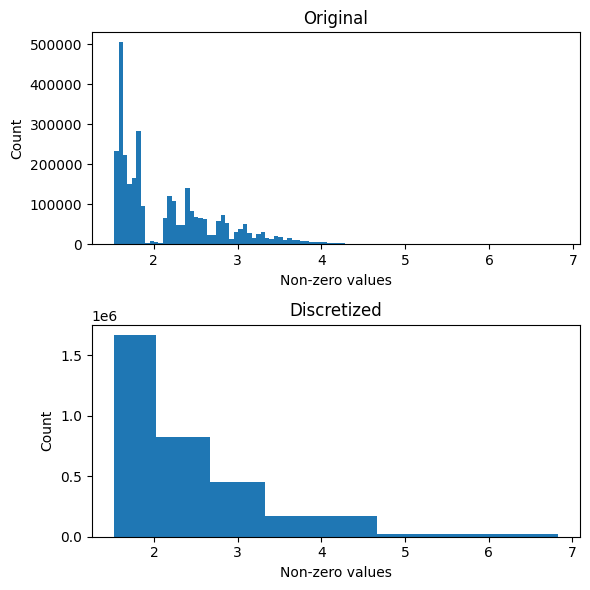

In [13]:
ug.tl.discretize(P22_RNA_adata_fltr,n_bins=5)
ug.pl.discretize(P22_RNA_adata_fltr,kde=False)
P22_RNA_adata_fltr.write(workdir+"/P22_RNA_adata_fltr_final.h5ad")

peak accessibility binarization

In [14]:
ug.pp.binarize(P22_ATAC_adata_fltr)
P22_ATAC_adata_fltr.write(workdir+"/P22_ATAC_adata_fltr_final.h5ad")

peak-motif relation

In [15]:
# Pure Python peak x motif scanning with defaults matching the motifmatchr workflow.
# Register the FASTA once per Python process; later scans only need peaks and genome.
ug.pp.register_genome(
    "mm10",
    ("/home/nas3/biod/yangchenghui/proj2/UniG_master/genomes/mm10/mm10.fa"),
)
peak_motif_matrix = ug.pp.peak_motif_matrix(
    P22_ATAC_adata_fltr.var_names,
    genome="mm10",
    n_jobs=min(8, mp.cpu_count()),
)

adata_PM = AnnData(peak_motif_matrix)
ug.pp.binarize(adata_PM)

adata_PM.write(workdir+"adata_PeakMotif_final.h5ad")
adata_PM

AnnData object with n_obs × n_vars = 50092 × 107

spatial spot-spot relation

In [16]:
adata_C_spatial = ug.tl.SpaNeighbor(P22_RNA_adata_fltr, k = 10)
adata_C_spatial.write(workdir+"spatial_InnerCell_final.h5ad")
adata_C_spatial

AnnData object with n_obs × n_vars = 9215 × 9215

# Generate graph

In [4]:
P22_RNA_adata_fltr = sc.read_h5ad(workdir+"/P22_RNA_adata_fltr_final.h5ad")
P22_ATAC_adata_fltr = sc.read_h5ad(workdir+"/P22_ATAC_adata_fltr_final.h5ad")

adata_PM = sc.read_h5ad(workdir+"/adata_PeakMotif_final.h5ad")
adata_GP = sc.read_h5ad(workdir+"/adata_GenePeak_final.h5ad")
adata_C_spatial = sc.read_h5ad(workdir+"/spatial_InnerCell_final.h5ad")

/tmp/ipykernel_479552/781386595.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(P22_RNA_adata_fltr, img_key=None, color=["label"],spot_size = 1)


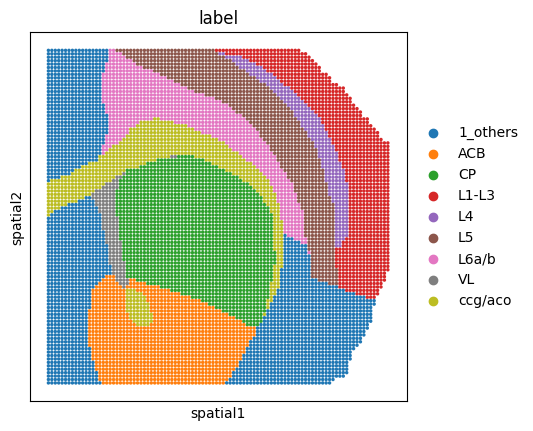

In [5]:
sc.pl.spatial(P22_RNA_adata_fltr, img_key=None, color=["label"],spot_size = 1)

In [6]:
ug.gen_graph(list_CP=[P22_ATAC_adata_fltr],
             list_CG=[P22_RNA_adata_fltr],
             list_PM=[adata_PM],
             list_CC_Spatial=[adata_C_spatial],
             list_GP=[adata_GP],
             weight_CP = 3,
             weight_PM = 1,
             weight_CC_Spatial = 5,
             weight_GP = 1,
             copy=False,
             dirname='graph_0')

`unig` does not exist in anndata 0 in `list_CP`.`.X` is being used instead.
relation0: source: C, destination: P
#edges: 17086303
`unig` does not exist in anndata 0 in `list_PM`.`.X` is being used instead.
relation1: source: P, destination: M
#edges: 619968
relation2: source: C, destination: G
#edges: 1669938
relation3: source: C, destination: G
#edges: 827549
relation4: source: C, destination: G
#edges: 450265
relation5: source: C, destination: G
#edges: 167361
relation6: source: C, destination: G
#edges: 20582
`unig` does not exist in anndata 0 in `list_CC_Spatial`.`.X` is being used instead.
relation7 (Spatial): source: C, destination: C
#edges: 101824
`unig` does not exist in anndata 0 in `list_GP`.`.X` is being used instead.
relation8: source: G, destination: P
#edges: 68171
Total number of edges: 21011961
Writing graph file "pbg_graph.txt" to "/home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/pbg/graph_0" ...
Finished.


# Training

In [7]:
pbg_training_stages = [
    {
        "name": "stage1_pretrain",
        "output": "model_0",
        "params": {
            "workers": 12,
            "lr": 0.1,
            "num_epochs": 10,
        },
    },
    {
        "name": "stage2_joint_finetune",
        "resume_from_previous": True,
        "params": {
            "workers": 12,
            "lr": 0.01,
            "num_epochs": 20,
            "alpha_ot_rna": 1e4,
            "alpha_ot_atac": 2e4,
            "alpha_triplet": 0,
            "alpha_ot_gp": 2000,
        },
    },
]

pbg_configs = ug.run_training_stages(
    base_params=ug.settings.pbg_params,
    stages=pbg_training_stages,
)

=============== Start stage1_pretrain ===============
Random seeds set to 42 for reproducibility
Auto-estimated weight decay: 1.686428E-03
Training mode: standard
Converting input data...
[2026-08-29 17:02:18.570144] Found some files that indicate that the input data has already been preprocessed, not doing it again.
[2026-08-29 17:02:18.570848] These files are in: /home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/pbg/graph_0/input/entity, /home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/pbg/graph_0/input/edge


Training config: 4 entities, 9 relations
Output directory: /home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/pbg/graph_0/model_0
Starting training...


/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/torchbiggraph/util.py:211: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage_type = dummy_tensor.storage_type()


Training completed
=============== Finished stage1_pretrain ===============
Resume checkpoint:
/home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/pbg/graph_0/model_0
=============== Start stage2_joint_finetune ===============
Random seeds set to 42 for reproducibility
Auto-estimated weight decay: 1.686428E-03
Training mode: joint (RNA-OT=10000, ATAC-OT=20000, GP-OT=2000)
Converting input data...
  Reading edge values from 4th column for downstream losses...
[2026-08-29 17:03:48.570957] Found some files that indicate that the input data has already been preprocessed, not doing it again.
[2026-08-29 17:03:48.571711] These files are in: /home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/pbg/graph_0/input/entity, /home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/pbg/graph_0/input/edge
Training config: 4 entities, 9 relations
Output directory: /home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/pbg/graph_0/model_0
Starting trai

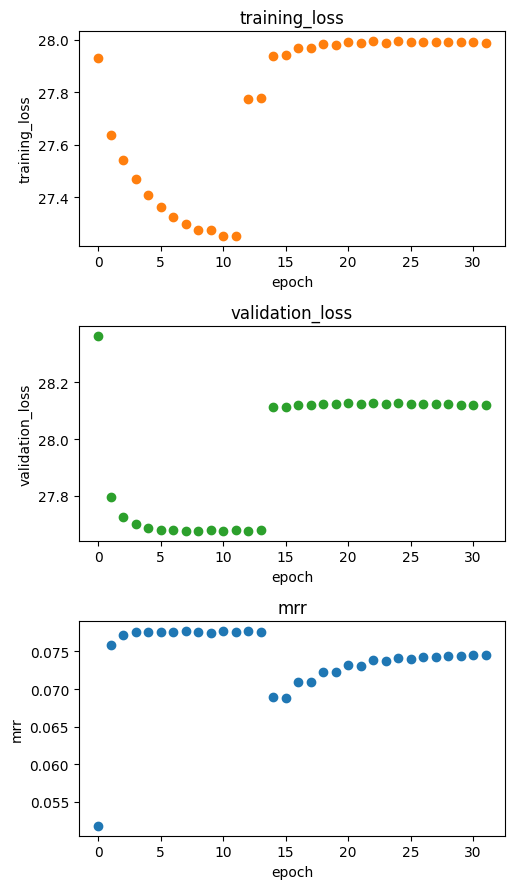

In [8]:
dict_config_s2 = pbg_configs["stage2_joint_finetune"]
ug.settings.pbg_params = dict_config_s2
ug.pl.pbg_metrics(fig_ncol=1)

# Post-training analysis

In [9]:
dict_adata = ug.tl.read_embedding()
dict_adata

{'C': AnnData object with n_obs × n_vars = 9215 × 50,
 'G': AnnData object with n_obs × n_vars = 1797 × 50,
 'M': AnnData object with n_obs × n_vars = 107 × 50,
 'P': AnnData object with n_obs × n_vars = 50092 × 50}

In [10]:
adata_C = dict_adata['C']
adata_G = dict_adata['G']  # embeddings for genes
adata_P = dict_adata['P']  # embeddings for peaks
adata_M = dict_adata['M']  # embeddings for motifs

adata_M.obs.index = 'M_'+adata_M.obs.index
adata_C.obs["entity_anno"] = "Cell"
adata_G.obs["entity_anno"] = "Gene"
adata_P.obs["entity_anno"] = "Peak"
adata_M.obs["entity_anno"] = "Motif"

adata_C.obs['celltype'] = P22_RNA_adata_fltr[adata_C.obs_names,:].obs['label'].copy()
adata_C.obsm['spatial'] = P22_RNA_adata_fltr[adata_C.obs_names,:].obsm['spatial'].copy()

visualize embeddings of cells

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


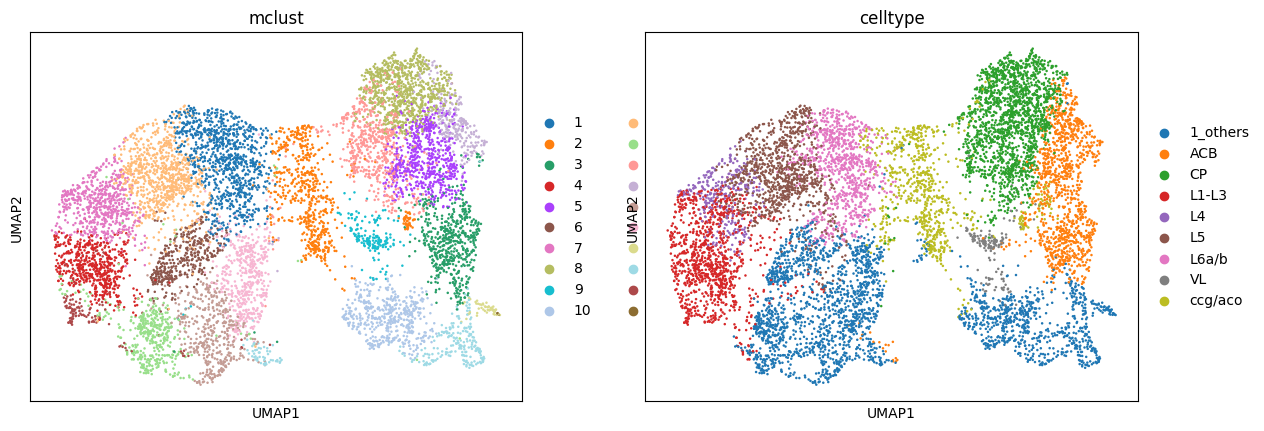

/tmp/ipykernel_4001079/3205255859.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_C, img_key=None, color=["mclust","celltype"],spot_size = 1)


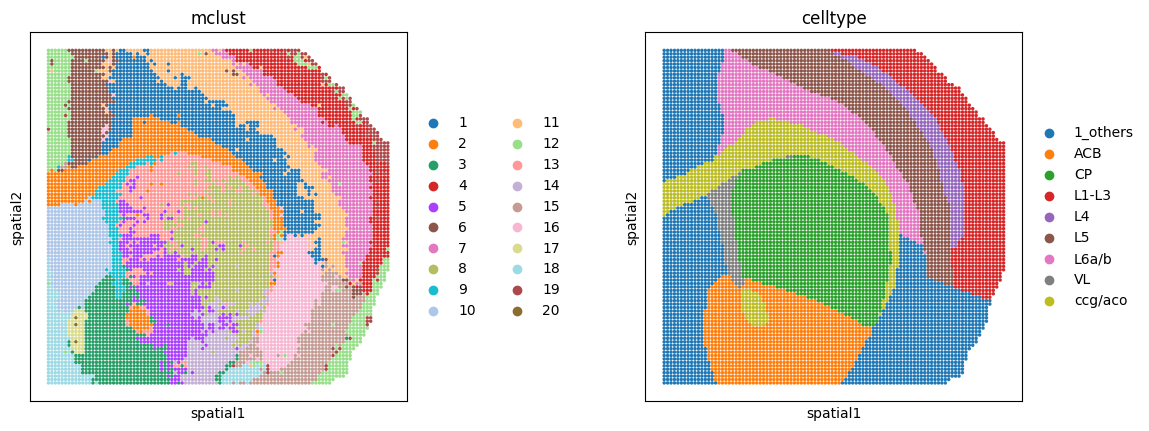

In [ ]:
sc.pp.neighbors(adata_C)
sc.tl.umap(adata_C)
ug.tl.mclust_R(adata_C,20,modelNames='EEI')
sc.pl.umap(adata_C, color=["mclust","celltype"])
sc.pl.spatial(adata_C, img_key=None, color=["mclust","celltype"],spot_size = 1)

In [ ]:
import pickle
adata_dict = {
    'C': adata_C,
    'G': adata_G,
    'P': adata_P,
    'M': adata_M
}

with open(workdir+'P22_UniG_adata_dict.pkl', 'wb') as f:
    pickle.dump(adata_dict, f)
print(f"Saved AnnData dictionary to {workdir+'P22_UniG_adata_dict.pkl'}")

Saved AnnData dictionary to /home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/P22_UniG_adata_dict.pkl


# Identification of TF regulatory activity 

Shuffle peak-motif links in UniG graph, keep rest unchanged, to mimic chromVAR's background removal.

In [4]:
P22_RNA_adata_fltr = sc.read_h5ad(workdir+"/P22_RNA_adata_fltr_final.h5ad")
P22_ATAC_adata_fltr = sc.read_h5ad(workdir+"/P22_ATAC_adata_fltr_final.h5ad")

adata_GP = sc.read_h5ad(workdir+"/adata_GenePeak_final.h5ad")
adata_C_spatial = sc.read_h5ad(workdir+"/spatial_InnerCell_final.h5ad")

In [5]:
adata_PM = sc.read_h5ad(workdir+"/adata_PeakMotif_final.h5ad")
adata_PM_background = ug.grn.shuffle_peak_motif(P22_ATAC_adata_fltr, adata_PM)
adata_PM_background

Step 1: Computing peak accessibility.
Step 2: Computing GC content.
Loading genome from /home/nas3/biod/yangchenghui/proj2/UniG_master/genomes/mm10/mm10.fa.


Calculating GC:   4%|▍         | 2200/50092 [00:00<00:02, 21992.68it/s]

Calculating GC: 100%|██████████| 50092/50092 [00:02<00:00, 22652.25it/s]


Step 3: Finding background peaks.
Background indices shape: (50092, 50)
Step 4: Loading peak-motif matrix.
Step 5: Generating background peak-motif matrix.


Processing motifs: 100%|██████████| 107/107 [00:01<00:00, 92.93it/s]


Finished background matrix: (50092, 107)


AnnData object with n_obs × n_vars = 50092 × 107

generate background graph and training

In [6]:
ug.gen_graph(list_CP=[P22_ATAC_adata_fltr],
             list_CG=[P22_RNA_adata_fltr],
             list_PM=[adata_PM_background],
             list_CC_Spatial=[adata_C_spatial],
             list_GP=[adata_GP],
             weight_CP = 3,
             weight_PM = 1,
             weight_CC_Spatial = 5,
             weight_GP = 1,
             copy=False,
             dirname='graph_bg')

`unig` does not exist in anndata 0 in `list_CP`.`.X` is being used instead.
relation0: source: C, destination: P
#edges: 17086303
`unig` does not exist in anndata 0 in `list_PM`.`.X` is being used instead.
relation1: source: P, destination: M
#edges: 620799
relation2: source: C, destination: G
#edges: 1669938
relation3: source: C, destination: G
#edges: 827549
relation4: source: C, destination: G
#edges: 450265
relation5: source: C, destination: G
#edges: 167361
relation6: source: C, destination: G
#edges: 20582
`unig` does not exist in anndata 0 in `list_CC_Spatial`.`.X` is being used instead.
relation7 (Spatial): source: C, destination: C
#edges: 101824
`unig` does not exist in anndata 0 in `list_GP`.`.X` is being used instead.
relation8: source: G, destination: P
#edges: 68171
Total number of edges: 21012792
Writing graph file "pbg_graph.txt" to "/home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/pbg/graph_bg" ...
Finished.


In [7]:
pbg_training_stages = [
    {
        "name": "stage1_pretrain",
        "output": "model_0",
        "params": {
            "workers": 12,
            "lr": 0.1,
            "num_epochs": 10,
        },
    },
    {
        "name": "stage2_joint_finetune",
        "resume_from_previous": True,
        "params": {
            "workers": 12,
            "lr": 0.01,
            "num_epochs": 20,
            "alpha_ot_rna": 1e4,
            "alpha_ot_atac": 2e4,
            "alpha_triplet": 0,
            "alpha_ot_gp": 2000,
        },
    },
]

pbg_configs = ug.run_training_stages(
    base_params=ug.settings.pbg_params,
    stages=pbg_training_stages,
)

=============== Start stage1_pretrain ===============
Random seeds set to 42 for reproducibility
Auto-estimated weight decay: 1.686361E-03
Training mode: standard
Converting input data...
[2026-08-30 08:04:09.591575] Using the 9 relation types given in the config
[2026-08-30 08:04:09.592283] Searching for the entities in the edge files...
[2026-08-30 08:04:29.780208] Entity type C:
[2026-08-30 08:04:29.782436] - Found 9215 entities
[2026-08-30 08:04:29.782892] - Removing the ones with fewer than 1 occurrences...
[2026-08-30 08:04:29.784797] - Left with 9215 entities
[2026-08-30 08:04:29.785262] - Shuffling them...
[2026-08-30 08:04:29.788751] Entity type G:
[2026-08-30 08:04:29.789112] - Found 1797 entities
[2026-08-30 08:04:29.789416] - Removing the ones with fewer than 1 occurrences...
[2026-08-30 08:04:29.789931] - Left with 1797 entities
[2026-08-30 08:04:29.790231] - Shuffling them...
[2026-08-30 08:04:29.791112] Entity type P:
[2026-08-30 08:04:29.791433] - Found 50092 entities
[

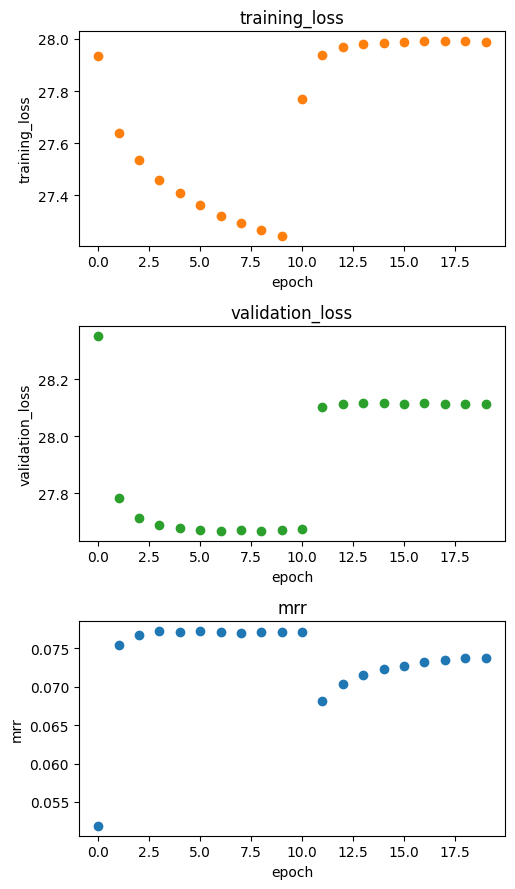

In [8]:
dict_config_s2 = pbg_configs["stage2_joint_finetune"]
ug.settings.pbg_params = dict_config_s2
ug.pl.pbg_metrics(fig_ncol=1)

In [9]:
dict_adata = ug.tl.read_embedding()
adata_C = dict_adata['C']
adata_G = dict_adata['G']  # embeddings for genes
adata_P = dict_adata['P']  # embeddings for peaks
adata_M = dict_adata['M']  # embeddings for motifs

adata_M.obs.index = 'M_'+adata_M.obs.index
adata_C.obs["entity_anno"] = "Cell"
adata_G.obs["entity_anno"] = "Gene"
adata_P.obs["entity_anno"] = "Peak"
adata_M.obs["entity_anno"] = "Motif"

adata_C.obs['celltype'] = P22_RNA_adata_fltr[adata_C.obs_names,:].obs['label'].copy()
adata_C.obsm['spatial'] = P22_RNA_adata_fltr[adata_C.obs_names,:].obsm['spatial'].copy()

In [10]:
import pickle
adata_dict = {
    'C': adata_C,
    'G': adata_G,
    'P': adata_P,
    'M': adata_M
}

with open(workdir+'P22_UniG_bg_adata_dict.pkl', 'wb') as f:
    pickle.dump(adata_dict, f)
print(f"Saved AnnData dictionary to {workdir+'P22_UniG_bg_adata_dict.pkl'}")

Saved AnnData dictionary to /home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/P22_UniG_bg_adata_dict.pkl


calculation of TF regulatory activity

In [4]:
# before correction
import pickle
with open(workdir+'P22_UniG_adata_dict.pkl', 'rb') as f:
    dict_adata = pickle.load(f)
adata_C = dict_adata['C']
adata_M = dict_adata['M']  # embeddings for motifs

# background
with open(workdir+'P22_UniG_bg_adata_dict.pkl', 'rb') as f:
    dict_adata = pickle.load(f)
adata_C_bg = dict_adata['C']
adata_M_bg = dict_adata['M']  # embeddings for motifs

# correct
adata_TF_expression = ug.grn.correct_TF_activity(adata_C,adata_M, adata_C_bg, adata_M_bg)
adata_TF_expression

AnnData object with n_obs × n_vars = 9215 × 107
    obs: 'entity_anno', 'celltype', 'mclust'
    var: 'entity_anno'
    obsm: 'spatial', 'X_umap'

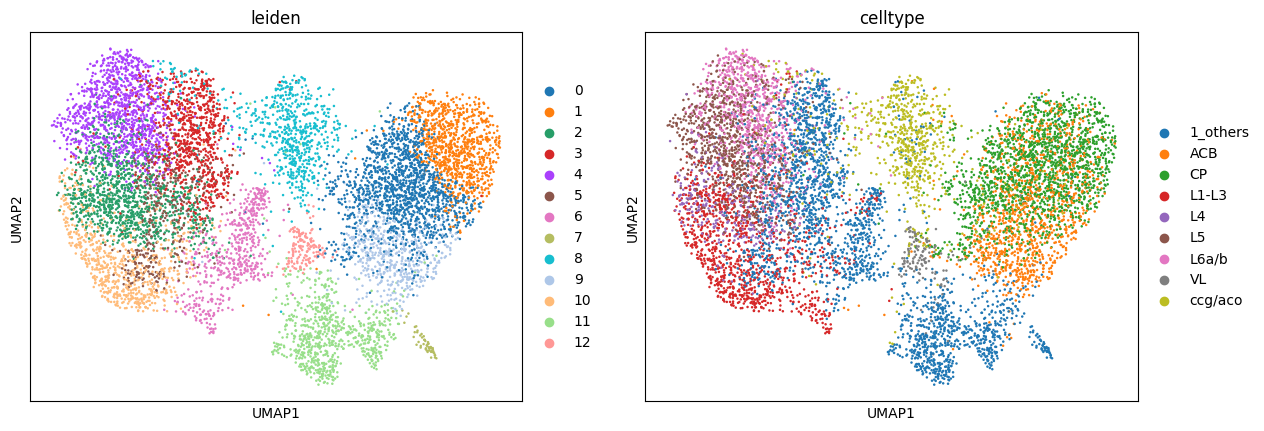

/tmp/ipykernel_2345047/3903759215.py:9: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key=None, color=["leiden","celltype"],spot_size = 1)


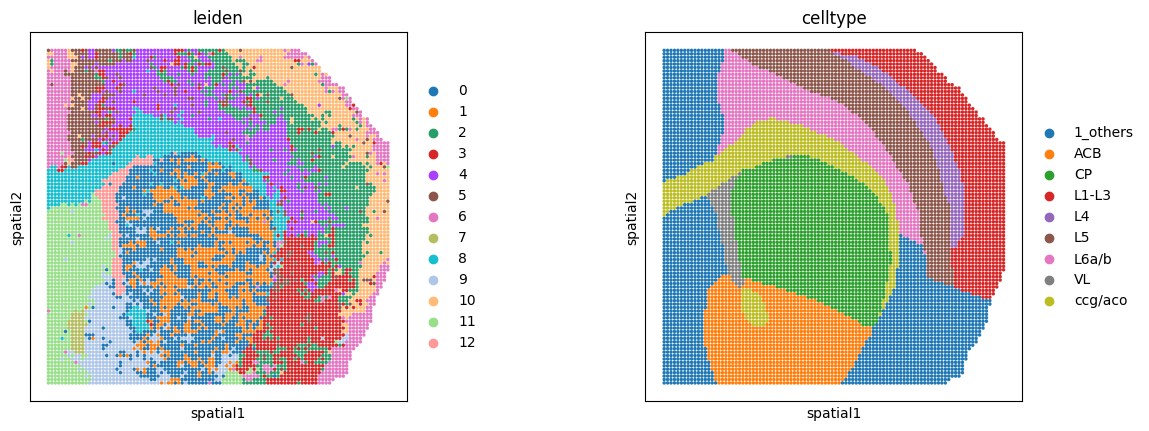

In [6]:
adata = adata_TF_expression.copy()

sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution= 1.1, flavor="igraph")
sc.pl.umap(adata, color=["leiden","celltype"])
sc.pl.spatial(adata, img_key=None, color=["leiden","celltype"],spot_size = 1)
adata.write(workdir+"P22_TF_regulatory_activity_adata.h5ad")

# Construction of cell-type specific GRNs 

In [4]:
adata_PM = sc.read_h5ad(workdir+"/adata_PeakMotif_final.h5ad")
adata_TF_expression = sc.read_h5ad(workdir+"P22_TF_regulatory_activity_adata.h5ad")

import pickle
with open(workdir+'P22_UniG_adata_dict.pkl', 'rb') as f:
    dict_adata = pickle.load(f)
adata_C = dict_adata['C']
adata_G = dict_adata['G']  # embeddings for genes
adata_P = dict_adata['P']  # embeddings for peaks
adata_M = dict_adata['M']  # embeddings for motifs
adata_C,adata_G,adata_P,adata_M

(AnnData object with n_obs × n_vars = 9215 × 50
     obs: 'entity_anno', 'celltype', 'mclust'
     uns: 'neighbors', 'umap', 'mclust_colors', 'celltype_colors'
     obsm: 'spatial', 'X_umap'
     obsp: 'distances', 'connectivities',
 AnnData object with n_obs × n_vars = 1797 × 50
     obs: 'entity_anno',
 AnnData object with n_obs × n_vars = 50092 × 50
     obs: 'entity_anno',
 AnnData object with n_obs × n_vars = 107 × 50
     obs: 'entity_anno')

cis-regulatory scores were calculated from FGOT.

In [5]:
# result from FGOT
gene_CRE_df = pd.read_csv('/home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/downstream_regulation/FGOT_result/P22_regulatory_cluster.csv')
gene_CRE_df

,gene,peak,score,celltype
0,A830036E02Rik,chr11:99182565-99183375,8.833433e-08,1
1,A830036E02Rik,chr11:99307294-99308133,2.751487e-08,1
2,A830036E02Rik,chr11:99430486-99431350,2.357593e-08,1
3,A830036E02Rik,chr11:99644169-99644869,7.726461e-08,1
4,A830036E02Rik,chr11:99398430-99399335,1.291017e-08,1
...,...,...,...,...
484715,Zmynd8,chr2:165976806-165977665,2.221235e-08,9
484716,Zmynd8,chr2:165852383-165853035,9.523063e-08,9
484717,Zmynd8,chr2:165782189-165783029,1.054297e-06,9
484718,Zmynd8,chr2:165992239-165993084,2.557712e-06,9


calculation cell type-specific GRNs

In [6]:
tf_gene_network = ug.grn.trans_GRN(adata_C, adata_G, adata_P, adata_M, adata_TF_expression, gene_CRE_df, adata_PM,
                 emb_cluster_key='mclust',
                 output_dir = workdir)
tf_gene_network


Starting GRN Inference Pipeline...
Filtering cell types...
Keeping cell types (19): ['1', '11', '8', '5', '2', '13', '7', '3', '4', '10', '16', '12', '15', '6', '14', '18', '9', '19', '17']
Removed cell types (<10 cells): {'20'}
Reconstructing expression matrices from embeddings...
Filtering CREs based on cell-type specificity...
Performing Gene-level Min-Max Normalization...
Filtering by gene group (Top 5%)...
Normalized Score limits: Min=0.05, Max Cap=0.5
CellType 1: Selected 172 validated peaks
CellType 10: Selected 423 validated peaks
CellType 11: Selected 29 validated peaks
CellType 12: Selected 712 validated peaks
CellType 13: Selected 289 validated peaks
CellType 14: Selected 1495 validated peaks
CellType 15: Selected 331 validated peaks
CellType 16: Selected 583 validated peaks
CellType 17: Selected 5666 validated peaks
CellType 18: Selected 962 validated peaks
CellType 19: Selected 2790 validated peaks
CellType 2: Selected 1092 validated peaks
CellType 3: Selected 83 validated

Processing Cell Types: 100%|██████████| 19/19 [00:04<00:00,  4.35it/s]


Saving results to /home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/...
GRN Inference Completed.


,TF,gene,regulatory_score,celltype
0,M_ARNT_HIF1A,Garnl3,0.133244,1
28579,M_ARNT_HIF1A,Tshz1,0.043002,17
28578,M_ARNT_HIF1A,Trank1,0.041377,17
28577,M_ARNT_HIF1A,Tpx2,0.017415,17
28576,M_ARNT_HIF1A,Tpm2,0.013882,17
...,...,...,...,...
56375,M_Znf281,Furin,0.582847,17
56374,M_Znf281,Fstl1,0.294572,17
56373,M_Znf281,Foxo1,0.455868,17
56349,M_Znf281,Dgkg,0.090794,17
